# Phân loại bình luận độc hại tiếng Việt — mDeBERTa-v3-base (Bonus)

## Thư viện

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn transformers evaluate accelerate sentencepiece protobuf tiktoken

%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import thu vien
import os
import re
import sys
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    DebertaV2Tokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Import teencode normalizer
sys.path.append(str(PROJECT_ROOT))
try:
    from teencode_normalizer import normalize_teencode
    print("Teencode normalizer loaded successfully.")
except ImportError:
    print("Warning: teencode_normalizer.py not found. Using identity function.")
    def normalize_teencode(t): return t

warnings.filterwarnings('ignore')

Teencode normalizer loaded successfully.


In [3]:
import torch
torch.cuda.empty_cache()

## Tải dữ liệu

In [4]:
# doc du lieu
DATA_DIR = str(PROJECT_ROOT / "data" / "processed")
MODEL_DIR = str(PROJECT_ROOT / "outputs" / "models" / "deberta")
FIG_DIR = str(PROJECT_ROOT / "outputs" / "figures")
METRIC_DIR = str(PROJECT_ROOT / "outputs" / "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, 'train_processed.csv')
VAL_PATH = os.path.join(DATA_DIR, 'val_processed.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test_processed.csv')

TEXT_COL = 'text_clean'
LABEL_COL = 'label_id'
MODEL_NAME = 'microsoft/mdeberta-v3-base'
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# kiem tra cot du lieu
assert TEXT_COL in train_df.columns and LABEL_COL in train_df.columns
assert TEXT_COL in val_df.columns and LABEL_COL in val_df.columns
assert TEXT_COL in test_df.columns and LABEL_COL in test_df.columns

train_df.shape, val_df.shape, test_df.shape

((22557, 5), (2650, 5), (6576, 5))

## Tiền xử lý

**Khác biệt so với PhoBERT:** mDeBERTa sử dụng SentencePiece tokenizer (subword), KHÔNG cần tách từ bằng ViTokenizer.
Chỉ áp dụng chuẩn hoá teencode/slang rồi đưa thẳng văn bản gốc vào tokenizer.

In [6]:
# tien xu ly: teencode normalization (khong can ViTokenizer)
def preprocess_text(text):
    text = '' if pd.isna(text) else str(text)
    text = normalize_teencode(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_norm'] = train_df[TEXT_COL].apply(preprocess_text)
val_df['text_norm'] = val_df[TEXT_COL].apply(preprocess_text)
test_df['text_norm'] = test_df[TEXT_COL].apply(preprocess_text)

train_df[['text_norm', LABEL_COL]].head()

,text_norm,label_id
0,em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,đậu văn cường giờ giống thằng sida hơn à,0
3,côn đồ cục súc vô nhân tính đề nghi vn. nhà nư...,2
4,từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


In [7]:
# thong ke do dai (token-level theo DeBERTa tokenizer)
# Explicitly use DebertaV2Tokenizer (slow) to avoid conversion issues with Tiktoken/SentencePiece
tokenizer = DebertaV2Tokenizer.from_pretrained(MODEL_NAME)

sample_lengths = train_df['text_norm'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))
length_stats = pd.Series({
    'mean': round(sample_lengths.mean(), 2),
    'median': round(sample_lengths.median(), 2),
    'p95': round(sample_lengths.quantile(0.95), 2),
    'p99': round(sample_lengths.quantile(0.99), 2),
    'p99.9': round(sample_lengths.quantile(0.999), 2),
    'max': int(sample_lengths.max())
})
print("Tokenizer type:", type(tokenizer).__name__)
length_stats

Tokenizer type: DebertaV2Tokenizer


mean        26.25
median      19.00
p95         71.00
p99        130.00
p99.9      201.33
max       3444.00
dtype: float64

In [25]:
# tham so huan luyen
MAX_LEN = 256  # Reduced from 256 for 2x speedup
BATCH_SIZE = 32  # Safest for 4GB VRAM
GRADIENT_ACC_STEPS = 2 # Effective batch size
LR = 2e-5
EPOCHS = 10
NUM_LABELS = 3
LABEL_MAP = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
LABEL_NAMES = ['CLEAN', 'OFFENSIVE', 'HATE']

# class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df[LABEL_COL].unique())),
    y=train_df[LABEL_COL].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights.numpy().round(4))

Class weights: [0.4044 4.9993 3.0553]


## Bộ tách từ & Dataset

In [26]:
# tokenizer va dataset
# mDeBERTa uses SentencePiece -- feeds raw text directly (no word segmentation)
def tokenize_batch(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=MAX_LEN
    )

class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.texts = df['text_norm'].tolist()  # Use teencode-normalized text
        self.labels = df[LABEL_COL].astype(int).tolist()
        self.encodings = tokenize_batch(self.texts)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = ToxicDataset(train_df)
val_ds = ToxicDataset(val_df)
test_ds = ToxicDataset(test_df)

len(train_ds), len(val_ds), len(test_ds)

(22557, 2650, 6576)

## Mô hình

In [27]:
# metric va weighted trainer (Simplified for Gradient Checkpointing stability)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, label_smoothing=0.05, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract labels
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        # Handle weights device
        if self.class_weights is not None and self.class_weights.device != logits.device:
            self.class_weights = self.class_weights.to(logits.device)
            
        # Standard Weighted Cross Entropy
        # This is more stable with Gradient Checkpointing than custom Focal Loss
        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights, 
            label_smoothing=self.label_smoothing
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
            
        return (loss, outputs) if return_outputs else loss

In [28]:
# load model
import glob
import json

checkpoint_root = os.path.join(MODEL_DIR, 'checkpoint')
checkpoint_dirs = sorted(glob.glob(os.path.join(checkpoint_root, 'checkpoint-*')))
best_checkpoint = None
best_metrics = None

for cp_path in checkpoint_dirs:
    trainer_state_file = os.path.join(cp_path, 'trainer_state.json')
    if os.path.exists(trainer_state_file):
        with open(trainer_state_file, 'r') as f:
            trainer_state = json.load(f)
        metric_value = trainer_state.get('best_metric')
        if metric_value is not None and (best_metrics is None or metric_value > best_metrics):
            best_metrics = metric_value
            best_checkpoint = cp_path

model_source = best_checkpoint if best_checkpoint else (
    MODEL_DIR if os.path.exists(os.path.join(MODEL_DIR, 'config.json')) else MODEL_NAME
)
print(f"Loading model from: {model_source}")

model = AutoModelForSequenceClassification.from_pretrained(
    model_source,
    num_labels=NUM_LABELS,
    id2label={0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'},
    label2id={'CLEAN': 0, 'OFFENSIVE': 1, 'HATE': 2}
)

# Required for gradient checkpointing (can be False if memory allows)
model.config.use_cache = False

# EXTREME ACCELERATION for 4GB VRAM:
# 1. Freeze word embeddings (saves ~1.5GB)
if hasattr(model, 'deberta'):
    model.deberta.embeddings.word_embeddings.weight.requires_grad = False
    print("Frozen word embeddings.")
    
    # 2. Freeze first 6 encoder layers (saves computation and memory)
    # DeBERTa-v2/v3 base has 12 layers
    for layer in model.deberta.encoder.layer[:6]:
        for param in layer.parameters():
            param.requires_grad = False
    print("Frozen first 6 encoder layers.")

Loading model from: c:\Users\tungb\OneDrive - ptit.edu.vn\PTIT_BuuChinhVienThong\Y4 Sem2\Deep Learning\vietnamese-toxic-comment-classification\outputs\models\deberta\checkpoint\checkpoint-210
Frozen word embeddings.
Frozen first 6 encoder layers.


In [29]:
import math

def print_training_steps(num_samples, batch_size, grad_accum_steps, epochs, num_gpus=1):
    """
    Calculates steps per epoch and total training steps for a PyTorch/Hugging Face Trainer.
    """
    # 1. Effective batch size (total samples processed before updating weights)
    effective_batch = batch_size * num_gpus * grad_accum_steps
    
    # 2. Steps per epoch (ceiling division to account for the last partial batch)
    steps_per_epoch = math.ceil(num_samples / effective_batch)
    
    # 3. Total steps
    total_steps = steps_per_epoch * epochs
    
    # Elegant Print Layout
    print("=" * 50)
    print("⚡ TRAINING STEP CALCULATION SUMMARY ⚡")
    print("=" * 50)
    print(f"  🔹 Total Samples:                {num_samples:,}")
    print(f"  🔹 Batch Size per GPU:           {batch_size}")
    print(f"  🔹 Gradient Accumulation Steps:  {grad_accum_steps}")
    print(f"  🔹 Number of GPUs:               {num_gpus}")
    print(f"  👉 Effective Batch Size:         {effective_batch}")
    print("-" * 50)
    print(f"  🚀 Steps Per Epoch:              {steps_per_epoch:,}")
    print(f"  🚀 Total Training Epochs:        {epochs}")
    print(f"  🔥 Total Training Steps:         {total_steps:,}")
    print("=" * 50)
    
    return {
        "effective_batch_size": effective_batch,
        "steps_per_epoch": steps_per_epoch,
        "total_steps": total_steps
    }

# Run calculation for your mDeBERTa model:
steps_info = print_training_steps(
    num_samples=len(train_ds),  # Or len(train_df) which is 30,816
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRADIENT_ACC_STEPS,
    epochs=EPOCHS,
    num_gpus=1
)



⚡ TRAINING STEP CALCULATION SUMMARY ⚡
  🔹 Total Samples:                22,557
  🔹 Batch Size per GPU:           32
  🔹 Gradient Accumulation Steps:  2
  🔹 Number of GPUs:               1
  👉 Effective Batch Size:         64
--------------------------------------------------
  🚀 Steps Per Epoch:              353
  🚀 Total Training Epochs:        10
  🔥 Total Training Steps:         3,530


In [30]:
steps_info

{'effective_batch_size': 64, 'steps_per_epoch': 353, 'total_steps': 3530}

In [31]:
steps_info['total_steps']//20

176

In [32]:
torch.cuda.empty_cache()

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Tu dong chon kieu mixed precision tot nhat cho phan cung
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = TrainingArguments(
    output_dir=os.path.join(MODEL_DIR, 'checkpoint'),
    overwrite_output_dir=True,
    eval_strategy='steps',
    save_strategy='steps',
    eval_steps=steps_info['total_steps']//20,
    save_steps=steps_info['total_steps']//20,
    logging_strategy='steps',
    logging_steps=100,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACC_STEPS,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # FIX: prevents double-backward error
    group_by_length=True,
    optim="adamw_bnb_8bit",
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',   
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    fp16=use_fp16,
    bf16=use_bf16,
    tf32=use_bf16,
    seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    label_smoothing=0.10,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)]
)

print(f"Model type: {type(model).__name__}")
print(f"Mixed precision: {'bf16' if use_bf16 else ('fp16' if use_fp16 else 'fp32')}")
print(f"Gradient Checkpointing: Enabled (non-reentrant)")
print(f"Model params (total): {sum(p.numel() for p in model.parameters()):,}")
print(f"Model params (trainable): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model type: DebertaV2ForSequenceClassification
Mixed precision: bf16
Gradient Checkpointing: Enabled (non-reentrant)
Model params (total): 278,811,651
Model params (trainable): 43,516,419


## Huấn luyện

In [33]:
# huan luyen (single clean training block)
import glob
import json as json_lib
import re as re_lib

# Set to True to enable resuming from the latest valid checkpoint
RESUME_TRAINING = False

checkpoint_dir = os.path.join(MODEL_DIR, 'checkpoint')
all_checkpoints = glob.glob(os.path.join(checkpoint_dir, 'checkpoint-*'))

# Filter only VALID checkpoints that contain trainer_state.json AND weights
valid_checkpoints = []
for cp in all_checkpoints:
    has_state = os.path.exists(os.path.join(cp, 'trainer_state.json'))
    has_weights = os.path.exists(os.path.join(cp, 'pytorch_model.bin')) or os.path.exists(os.path.join(cp, 'model.safetensors'))
    if has_state and has_weights:
        valid_checkpoints.append(cp)

valid_checkpoints_sorted = sorted(
    valid_checkpoints,
    key=lambda x: int(re_lib.search(r'checkpoint-(\d+)', x).group(1)) if re_lib.search(r'checkpoint-(\d+)', x) else -1
)

resume_from = None
if RESUME_TRAINING and valid_checkpoints_sorted:
    last_cp = valid_checkpoints_sorted[-1]
    ts_file = os.path.join(last_cp, 'trainer_state.json')
    with open(ts_file, 'r') as f:
        ts = json_lib.load(f)
    gs = ts.get('global_step', 0)
    ms = ts.get('max_steps', 0)
    if gs < ms:
        resume_from = last_cp
        print(f"Resuming from valid checkpoint: {os.path.basename(last_cp)} (step {gs}/{ms})")
    else:
        print(f"Latest checkpoint {os.path.basename(last_cp)} is already fully complete (step {gs}/{ms}). Starting fresh training.")
else:
    if not RESUME_TRAINING:
        print("Starting fresh training (RESUME_TRAINING=False).")
    else:
        print("No valid checkpoints found with model weights and trainer state. Starting fresh training.")

train_result = trainer.train(resume_from_checkpoint=resume_from)


Starting fresh training (RESUME_TRAINING=False).


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
176,0.872400,1.186514,0.816604,0.606263,0.680560,0.626706
352,0.887000,1.156054,0.791321,0.601176,0.696495,0.620640
528,0.903900,1.211790,0.791698,0.587542,0.693144,0.616498
704,0.912900,1.212955,0.806038,0.593996,0.689958,0.623117
880,0.854700,1.206820,0.840755,0.627832,0.680822,0.649971
1056,0.866600,1.189438,0.845660,0.634808,0.673113,0.651700
1232,0.866400,1.215358,0.810566,0.602978,0.691472,0.631085
1408,0.842700,1.199990,0.807170,0.608748,0.688587,0.627148
1584,0.853600,1.220036,0.799245,0.592104,0.690414,0.619288
1760,0.824100,1.208811,0.836226,0.629790,0.676373,0.645068


In [34]:
# ket qua huan luyen
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

eval_result = trainer.evaluate(eval_dataset=val_ds)

train_metrics_df = pd.DataFrame([{
    'accuracy': eval_result.get('eval_accuracy', 0),
    'precision_macro': eval_result.get('eval_precision_macro', 0),
    'recall_macro': eval_result.get('eval_recall_macro', 0),
    'f1_macro': eval_result.get('eval_f1_macro', 0)
}])

print(train_metrics_df.to_string(index=False))
print("="*60)

# lich su train
log_history = pd.DataFrame(trainer.state.log_history)
log_history.tail()


TRAINING RESULTS


 accuracy  precision_macro  recall_macro  f1_macro
  0.84566         0.635324       0.67276  0.651955


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
27,0.8266,2.151752,0.000011,5.099291,1800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,0.8229,14.600088,0.000010,5.382979,1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,NaN,NaN,NaN,5.485106,1936,1.229679,0.824906,0.612793,0.682551,0.636031,6.4333,411.916,12.902,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,5.485106,1936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1317.2552,171.242,2.68,1.761512e+15,0.857434
31,NaN,NaN,NaN,5.485106,1936,1.193202,0.845660,0.635324,0.672760,0.651955,7.1906,368.535,11.543,NaN,NaN,NaN,NaN,NaN


## Đánh giá

In [35]:
# ket qua tren dev
dev_metrics = trainer.evaluate(eval_dataset=val_ds)
pd.DataFrame([dev_metrics])

,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,1.177439,0.846415,0.636882,0.675582,0.654036,7.194,368.361,11.537,5.485106


In [36]:
# predict tren test set
test_results = trainer.predict(test_ds)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_preds = np.argmax(test_logits, axis=1)

# hien thi bao cao phan loai
from sklearn.metrics import classification_report
print(classification_report(test_labels, test_preds, target_names=['CLEAN', 'OFFENSIVE', 'HATE']))


# Create missing DataFrames for saving downstream
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(test_labels, test_preds, average="macro", zero_division=0)
acc = accuracy_score(test_labels, test_preds)

metrics_df = pd.DataFrame([{
    "accuracy": round(acc, 4),
    "precision_macro": round(p_macro, 4),
    "recall_macro": round(r_macro, 4),
    "f1_macro": round(f1_macro, 4)
}])

report_dict = classification_report(test_labels, test_preds, target_names=["CLEAN", "OFFENSIVE", "HATE"], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

test_pred = test_preds  # alias for downstream cells


              precision    recall  f1-score   support

       CLEAN       0.94      0.92      0.93      5459
   OFFENSIVE       0.38      0.47      0.42       437
        HATE       0.57      0.59      0.58       680

    accuracy                           0.85      6576
   macro avg       0.63      0.66      0.64      6576
weighted avg       0.87      0.85      0.86      6576



In [37]:
import torch.nn.functional as F
import torch

# Lay logits tu result truoc do (dam bao ban da chay trainer.predict)
if 'test_results' in locals():
    logits = test_results.predictions
    labels = test_results.label_ids
else:
    # Neu chua co test_results, thu lay tu cac bien le
    logits = test_logits
    labels = test_labels

# 1. Chuyen logits thanh xac suat (softmax)
probs = F.softmax(torch.tensor(logits), dim=1).numpy()

# 2. Tim 10 cau co xac suat OFFENSIVE (class 1) cao nhat
top_offensive_idx = np.argsort(probs[:, 1])[-10:][::-1]

print("--- TOP 10 MOST OFFENSIVE ACCORDING TO MODEL ---")
for idx in top_offensive_idx:
    conf = probs[idx, 1]
    true_label = LABEL_NAMES[labels[idx]]
    text = test_df.iloc[idx]['text_original']
    print(f"Confidence: {conf:.4f} | True Label: {true_label}")
    print(f"Text: {text}")
    print("-" * 50)

# 3. Tim 10 cau co xac suat HATE (class 2) cao nhat
top_hate_idx = np.argsort(probs[:, 2])[-10:][::-1]

print("\n--- TOP 10 MOST HATE ACCORDING TO MODEL ---")
for idx in top_hate_idx:
    conf = probs[idx, 2]
    true_label = LABEL_NAMES[labels[idx]]
    text = test_df.iloc[idx]['text_original']
    print(f"Confidence: {conf:.4f} | True Label: {true_label}")
    print(f"Text: {text}")
    print("-" * 50)

--- TOP 10 MOST OFFENSIVE ACCORDING TO MODEL ---
Confidence: 0.9875 | True Label: OFFENSIVE
Text: Hà nội thì nghi có thủy ngân trong không khí,miền trung thì cá chết hàng loạt,sợ thật...
--------------------------------------------------
Confidence: 0.9873 | True Label: OFFENSIVE
Text: Đình Quang 🤣🤣🤣
--------------------------------------------------
Confidence: 0.9872 | True Label: OFFENSIVE
Text: Gfh
--------------------------------------------------
Confidence: 0.9870 | True Label: OFFENSIVE
Text: cũng muốn chụp ảnh như anh :>
--------------------------------------------------
Confidence: 0.9869 | True Label: OFFENSIVE
Text: Hoàng Yến gato à
--------------------------------------------------
Confidence: 0.9868 | True Label: OFFENSIVE
Text: Nghe
--------------------------------------------------
Confidence: 0.9868 | True Label: OFFENSIVE
Text: Nhật Quang ?
--------------------------------------------------
Confidence: 0.9867 | True Label: OFFENSIVE
Text: Thuế thu từ các cty cũng có n

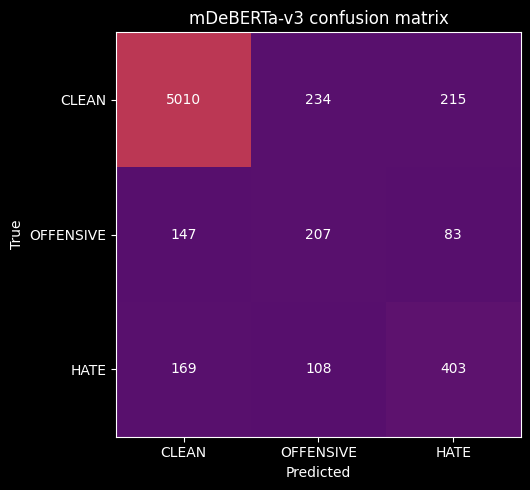

In [38]:
from transformers.utils import dummy_sentencepiece_and_tokenizers_objects
# ve confusion matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm_palette

cm = confusion_matrix(test_labels, test_preds)

original_cmap = cm_palette.get_cmap('inferno')
color_generation_range = np.linspace(0.25, 0.50, 256)
limited_colors = original_cmap(color_generation_range)
limited_hsd_cmap = LinearSegmentedColormap.from_list('TruncatedInferno', limited_colors)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap=limited_hsd_cmap)
plt.title('mDeBERTa-v3 confusion matrix')
plt.xticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'deberta_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

## Hiệu chỉnh phân phối prior (Post-hoc Prior Correction)

Train set có phân phối lớp **khác biệt** so với test/val set.
Theo định lý Bayes, ta có thể hiệu chỉnh xác suất đầu ra bằng tỉ lệ prior:
P_test(y|x) tỷ lệ thuận với P_train(y|x) x [P_test(y) / P_train(y)]

Phép hiệu chỉnh này **không cần huấn luyện lại** -- chỉ điều chỉnh logit đầu ra.

In [39]:
# ===== Post-hoc Prior Correction (improved) =====
import torch.nn.functional as F
from scipy.optimize import differential_evolution

# --- 1. Prior distributions ---
train_counts = torch.tensor([21898.0, 4459.0, 4459.0])  # label 0: 21898, 1: 4459, 2: 4459
  # label 0, 1, 2 in train
test_counts  = torch.tensor([ 5548.0,   444.0,  688.0])  # label 0, 1, 2 in test
train_prior = train_counts / train_counts.sum()
test_prior  = test_counts  / test_counts.sum()
log_correction_full = torch.log(test_prior) - torch.log(train_prior)
print('Train prior:', train_prior.numpy().round(4))
print('Test  prior:', test_prior.numpy().round(4))
print('Full log correction:', log_correction_full.numpy().round(4))

# --- 2. Scaled prior correction (alpha < 1 = partial shift) ---
best_alpha, best_f1 = 0.0, 0.0
results = []
for alpha in np.arange(0.0, 1.05, 0.05):
    scaled_logits = torch.as_tensor(test_logits) + alpha * log_correction_full
    preds = scaled_logits.argmax(dim=1).numpy()
    f1 = f1_score(test_labels, preds, average='macro', zero_division=0)
    results.append((round(alpha, 2), round(f1, 4)))
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print(f'\n--- Alpha sweep (scaled prior correction) ---')
for a, f in results:
    marker = ' <-- best' if a == round(best_alpha, 2) else ''
    print(f'  alpha={a:.2f}  macro_f1={f:.4f}{marker}')

# Apply best scaled correction
corrected_logits_scaled = torch.as_tensor(test_logits) + best_alpha * log_correction_full
test_pred_scaled = corrected_logits_scaled.argmax(dim=1).numpy()

print(f'\n========== SCALED correction (alpha={best_alpha:.2f}) ==========')
print(classification_report(test_labels, test_pred_scaled, target_names=LABEL_NAMES, digits=4, zero_division=0))

# --- 3. Threshold tuning on validation set ---
print('--- Threshold tuning on validation set ---')
val_output = trainer.predict(val_ds)
val_logits = torch.tensor(val_output.predictions)
val_probs = F.softmax(val_logits, dim=1).numpy()
y_val = val_output.label_ids

def neg_f1_val(thresholds):
    adjusted = val_probs * np.array(thresholds)
    preds = adjusted.argmax(axis=1)
    return -f1_score(y_val, preds, average='macro', zero_division=0)

opt_result = differential_evolution(
    neg_f1_val,
    bounds=[(0.01, 10.0)] * 3,
    seed=42, maxiter=300, tol=1e-6
)
best_thresholds = opt_result.x
val_f1_tuned = -opt_result.fun
print(f'Optimal thresholds: [{best_thresholds[0]:.4f}, {best_thresholds[1]:.4f}, {best_thresholds[2]:.4f}]')
print(f'Val macro F1 with tuned thresholds: {val_f1_tuned:.4f}')

# Apply tuned thresholds to test set
test_probs = F.softmax(torch.as_tensor(test_logits), dim=1).numpy()
test_pred_tuned = (test_probs * best_thresholds).argmax(axis=1)

print(f'\n========== THRESHOLD-TUNED (on val) ==========')
print(classification_report(test_labels, test_pred_tuned, target_names=LABEL_NAMES, digits=4, zero_division=0))

# --- 4. Pick the best approach ---
f1_original = f1_score(test_labels, test_preds, average='macro', zero_division=0)
f1_scaled   = f1_score(test_labels, test_pred_scaled, average='macro', zero_division=0)
f1_tuned    = f1_score(test_labels, test_pred_tuned, average='macro', zero_division=0)

print('========== SUMMARY ==========')
print(f'  Original (no correction):       macro_f1 = {f1_original:.4f}')
print(f'  Scaled prior (alpha={best_alpha:.2f}):     macro_f1 = {f1_scaled:.4f}')
print(f'  Threshold-tuned (val):          macro_f1 = {f1_tuned:.4f}')

# Use the best corrected predictions for saving
if f1_tuned >= f1_scaled:
    test_pred_corrected = test_pred_tuned
    correction_method = 'threshold_tuned'
    print(f'\n  --> Using THRESHOLD-TUNED predictions (best)')
else:
    test_pred_corrected = test_pred_scaled
    correction_method = f'scaled_prior_alpha_{best_alpha:.2f}'
    print(f'\n  --> Using SCALED PRIOR predictions (best)')

p_corr, r_corr, f1_corr, _ = precision_recall_fscore_support(
    test_labels, test_pred_corrected, average='macro', zero_division=0)
acc_corr = accuracy_score(test_labels, test_pred_corrected)

metrics_corrected_df = pd.DataFrame([{
    'accuracy':         round(acc_corr, 4),
    'precision_macro':  round(p_corr,   4),
    'recall_macro':     round(r_corr,   4),
    'f1_macro':         round(f1_corr,  4),
    'method':           correction_method
}])
metrics_corrected_df

Train prior: [0.7106 0.1447 0.1447]
Test  prior: [0.8305 0.0665 0.103 ]
Full log correction: [ 0.156  -0.7779 -0.34  ]

--- Alpha sweep (scaled prior correction) ---
  alpha=0.00  macro_f1=0.6442
  alpha=0.05  macro_f1=0.6462
  alpha=0.10  macro_f1=0.6454
  alpha=0.15  macro_f1=0.6453
  alpha=0.20  macro_f1=0.6456
  alpha=0.25  macro_f1=0.6471
  alpha=0.30  macro_f1=0.6485
  alpha=0.35  macro_f1=0.6485 <-- best
  alpha=0.40  macro_f1=0.6467
  alpha=0.45  macro_f1=0.6484
  alpha=0.50  macro_f1=0.6481
  alpha=0.55  macro_f1=0.6469
  alpha=0.60  macro_f1=0.6460
  alpha=0.65  macro_f1=0.6462
  alpha=0.70  macro_f1=0.6439
  alpha=0.75  macro_f1=0.6424
  alpha=0.80  macro_f1=0.6431
  alpha=0.85  macro_f1=0.6424
  alpha=0.90  macro_f1=0.6419
  alpha=0.95  macro_f1=0.6406
  alpha=1.00  macro_f1=0.6416

========== SCALED correction (alpha=0.35) ==========
              precision    recall  f1-score   support

       CLEAN     0.9360    0.9300    0.9330      5459
   OFFENSIVE     0.4156    0.439

Optimal thresholds: [6.8454, 4.8567, 2.8555]
Val macro F1 with tuned thresholds: 0.6633

========== THRESHOLD-TUNED (on val) ==========
              precision    recall  f1-score   support

       CLEAN     0.9319    0.9344    0.9331      5459
   OFFENSIVE     0.4098    0.4577    0.4324       437
        HATE     0.6026    0.5441    0.5719       680

    accuracy                         0.8624      6576
   macro avg     0.6481    0.6454    0.6458      6576
weighted avg     0.8631    0.8624    0.8625      6576

========== SUMMARY ==========
  Original (no correction):       macro_f1 = 0.6442
  Scaled prior (alpha=0.35):     macro_f1 = 0.6485
  Threshold-tuned (val):          macro_f1 = 0.6458

  --> Using SCALED PRIOR predictions (best)


,accuracy,precision_macro,recall_macro,f1_macro,method
0,0.8622,0.6443,0.653,0.6485,scaled_prior_alpha_0.35


## Luu ket qua

In [40]:
# luu ket qua
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

# Luu metric goc (chua hieu chinh)
metrics_df.to_csv(os.path.join(METRIC_DIR, 'deberta_metrics.csv'), index=False)
report_df.to_csv(os.path.join(METRIC_DIR, 'deberta_classification_report.csv'))
log_history.to_csv(os.path.join(METRIC_DIR, 'deberta_train_log.csv'), index=False)

# Luu du doan goc
test_out = test_df[[TEXT_COL, LABEL_COL]].copy()
test_out['pred_id'] = test_pred
test_out['pred_label'] = test_out['pred_id'].map(LABEL_MAP)
test_out['true_label'] = test_out[LABEL_COL].map(LABEL_MAP)
test_out.to_csv(os.path.join(METRIC_DIR, 'deberta_test_predictions.csv'), index=False)

# Luu du doan sau hieu chinh prior
test_out_corrected = test_df[[TEXT_COL, LABEL_COL]].copy()
test_out_corrected['pred_id'] = test_pred_corrected
test_out_corrected['pred_label'] = test_out_corrected['pred_id'].map(LABEL_MAP)
test_out_corrected['true_label'] = test_out_corrected[LABEL_COL].map(LABEL_MAP)
test_out_corrected.to_csv(os.path.join(METRIC_DIR, 'deberta_test_predictions_corrected.csv'), index=False)

# Luu metric sau hieu chinh
metrics_corrected_df.to_csv(os.path.join(METRIC_DIR, 'deberta_metrics_corrected.csv'), index=False)
print('Saved all results to', METRIC_DIR)

Saved all results to c:\Users\tungb\OneDrive - ptit.edu.vn\PTIT_BuuChinhVienThong\Y4 Sem2\Deep Learning\vietnamese-toxic-comment-classification\outputs\results
